In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from torchvision import transforms
from torch.utils.data import DataLoader
from pycocotools.coco import COCO
from PIL import Image

class CocoSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, ann_path, transforms=None):
        self.coco = COCO(ann_path)
        self.img_dir = img_dir
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = img_info['file_name']
        img = cv2.imread(os.path.join(self.img_dir, path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        for ann in anns:
            rle = self.coco.annToMask(ann)
            mask = np.maximum(mask, rle * ann['category_id'])

        if self.transforms:
            img = self.transforms(img)
            mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)
        return img, torch.tensor(mask, dtype=torch.long)

    def __len__(self):
        return len(self.ids)

In [2]:

from torchvision.models.segmentation import deeplabv3_resnet101

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = deeplabv3_resnet101(pretrained=False, num_classes=2)
model.load_state_dict(torch.load('deeplabv3_model_epoch1.pth', map_location=device))
model.to(device)
model.eval()

/Users/rahularutla/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/rahularutla/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/var/folders/c7/gjbfmqw50_n042sn1snttvw40000gn/T/ipykernel_36226/3274589237.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the de

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [3]:

tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_dataset = CocoSegmentationDataset("same-object-images", "same-object-val.json", transforms=tfms)
test_dataset = CocoSegmentationDataset("same-object-images", "same-object-test.json", transforms=tfms)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [5]:

os.makedirs("output_masks", exist_ok=True)
print("Saving all test predictions to output_masks/ ...")

with torch.no_grad():
    for i, (img, _) in enumerate(test_loader):
        img = img.to(device)
        output = model(img)['out']
        pred_mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy().astype(np.uint8) * 255
        cv2.imwrite(f"output_masks/test_mask_{i:04d}.png", pred_mask)

print("✅ Done! All test masks saved.")

Saving all test predictions to output_masks/ ...
✅ Done! All test masks saved.


In [7]:
def calculate_mean_iou(loader, model, num_classes=2):
    iou_scores = []

    with torch.no_grad():
        for imgs, true_masks in loader:
            imgs = imgs.to(device)
            true_masks = true_masks.to(device)

            outputs = model(imgs)['out']
            preds = torch.argmax(outputs.squeeze(), dim=0)

            for cls in range(num_classes):
                pred_inds = preds == cls
                target_inds = true_masks.squeeze() == cls
                intersection = (pred_inds & target_inds).sum().float()
                union = (pred_inds | target_inds).sum().float()
                if union == 0:
                    continue  # skip classes not present
                iou = intersection / union
                iou_scores.append(iou.item())

    return sum(iou_scores) / len(iou_scores) if iou_scores else 0.0


In [8]:
mean_iou = calculate_mean_iou(val_loader, model)
print(f"📊 Mean IoU on Validation Set: {mean_iou:.4f}")


📊 Mean IoU on Validation Set: 0.9609


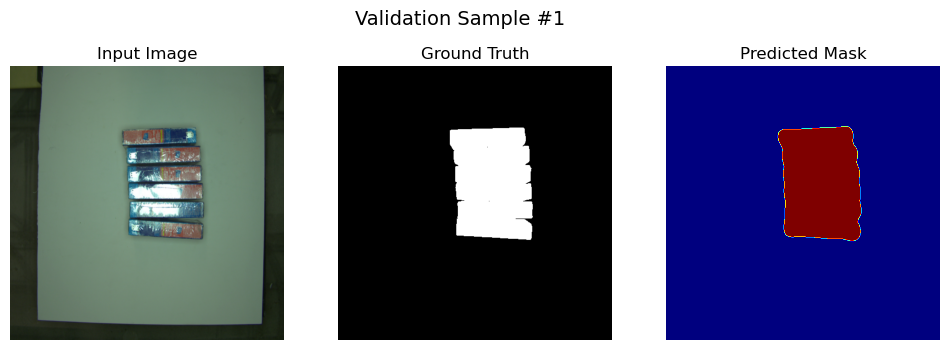

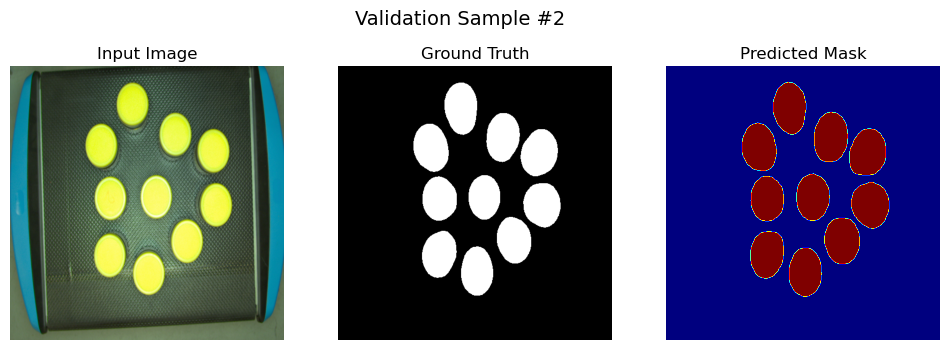

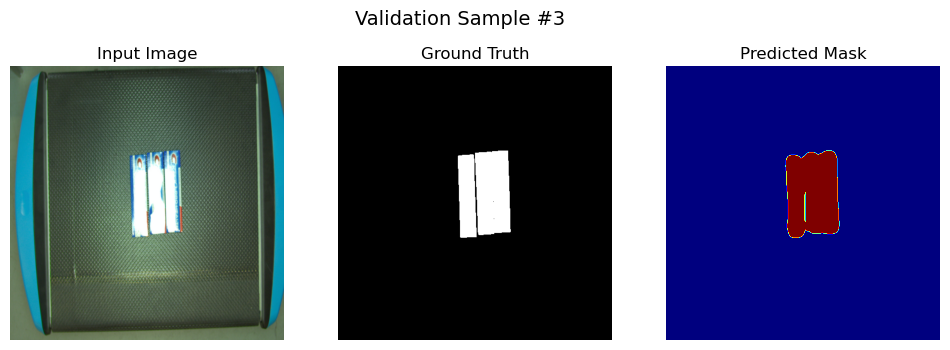

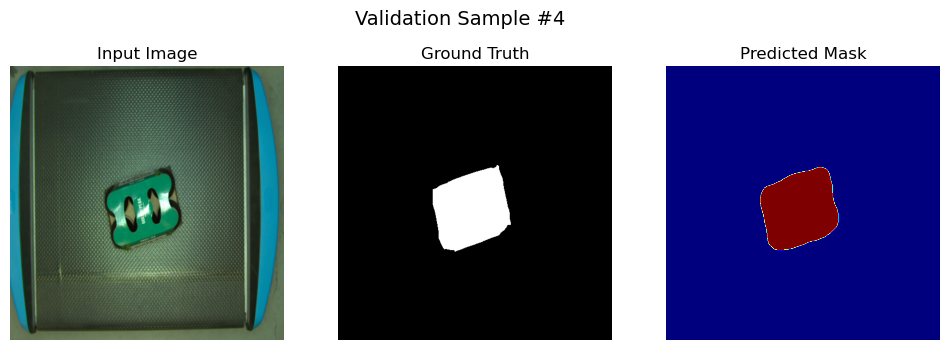

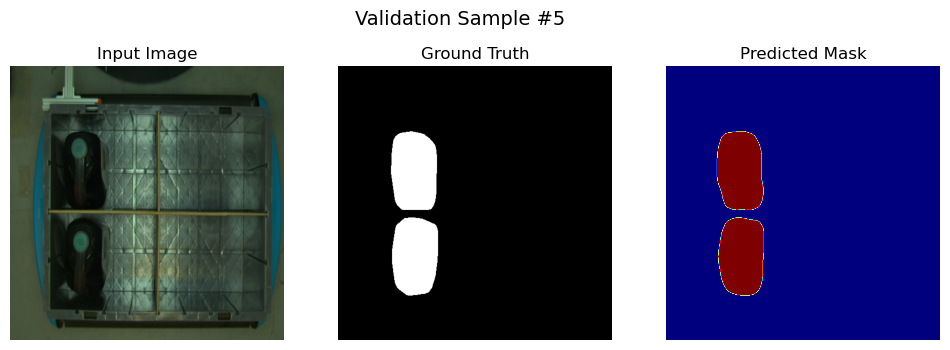

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def show_predictions(loader, model, num_samples=5, title="Validation"):
    with torch.no_grad():
        for i, (img, mask) in enumerate(loader):
            if i >= num_samples:
                break
            img = img.to(device)
            output = model(img)['out']
            pred_mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy()
            true_mask = mask.squeeze().cpu().numpy()

            img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
            img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
            img_np = (img_np * 255).astype(np.uint8)

            plt.figure(figsize=(12, 4))
            plt.suptitle(f"{title} Sample #{i+1}", fontsize=14)

            plt.subplot(1, 3, 1)
            plt.imshow(img_np)
            plt.title("Input Image")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask, cmap='gray')
            plt.title("Ground Truth")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask, cmap='jet')
            plt.title("Predicted Mask")
            plt.axis('off')

            plt.show()

show_predictions(val_loader, model)


In [11]:
mean_iou = calculate_mean_iou(test_loader, model)
print(f"📊 Mean IoU on Test Set: {mean_iou:.4f}")

📊 Mean IoU on Test Set: 0.9604
